# Task 2 — Qiskit Circuits (LO1, LO2)
**MSE802 Quantum Computing — Assessment 2**

This task has two parts:

- **Part A:** build the given circuit — **H on q0, X on q1**, measured into block **C** — using **Qiskit**, and run it on the **Quokka** device.
- **Part B:** write our **own QASM** circuit using different qubits and various gates, and run it on Quokka.

## Part A — the H / X circuit

The specified circuit applies a **Hadamard (H)** to the top qubit and a **Pauli-X (X)** to the
bottom qubit, then measures both (block **C** = the measurement / classical readout):

```
 q0 ──[ H ]──┐
             ├──[ C ]── (measure)
 q1 ──[ X ]──┘
```

**What to expect:**
- **X on q1** is a deterministic bit-flip: $|0\rangle \to |1\rangle$, so q1 is **always 1**.
- **H on q0** creates a superposition: q0 is a **50/50 coin flip** between 0 and 1.

So measurements should yield only two outcomes, each ~50%.

### A.1 Build the circuit in Qiskit

In [1]:
from qiskit import QuantumCircuit

# 2 quantum bits, 2 classical bits to store the measurements
qc = QuantumCircuit(2, 2)
qc.h(0)                    # Hadamard on q0  -> superposition
qc.x(1)                    # Pauli-X on q1   -> bit-flip |0> to |1>
qc.measure([0, 1], [0, 1]) # block C: measure q0->c0, q1->c1

print(qc.draw(output="text"))

     ┌───┐┌─┐   
q_0: ┤ H ├┤M├───
     ├───┤└╥┘┌─┐
q_1: ┤ X ├─╫─┤M├
     └───┘ ║ └╥┘
c: 2/══════╩══╩═
           0  1 


### A.2 Simulate locally

We use Qiskit's built-in `StatevectorSampler` (no extra packages needed) for 1000 shots.

**Reading the result — important Qiskit convention:** bitstrings are printed **little-endian**
as `c[1] c[0]` (q1 on the **left**, q0 on the **right**). So `'10'` means q1 = 1, q0 = 0.

In [2]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1000).result()
counts = result[0].data.c.get_counts()
print("Counts (c1 c0):", counts)

Counts (c1 c0): {'10': 518, '11': 482}


### A.3 Visualise

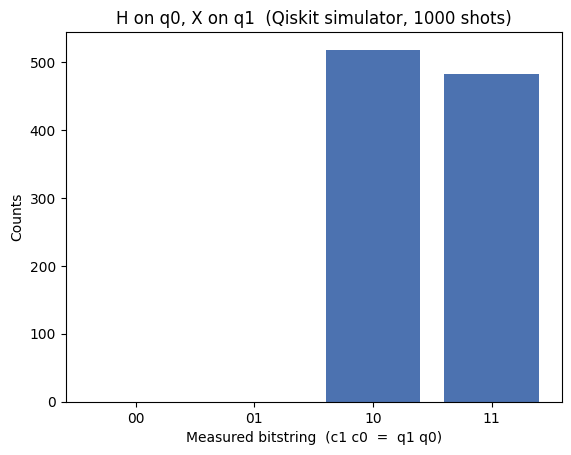

In [3]:
import matplotlib.pyplot as plt

labels = ["00", "01", "10", "11"]
values = [counts.get(b, 0) for b in labels]
plt.bar(labels, values, color="#4C72B0")
plt.title("H on q0, X on q1  (Qiskit simulator, 1000 shots)")
plt.xlabel("Measured bitstring  (c1 c0  =  q1 q0)")
plt.ylabel("Counts")
plt.show()

**Observation:** only `10` and `11` appear (~50/50). The left bit (q1) is always 1 because of the
X gate; the right bit (q0) is random because of the H gate. This single circuit shows both a
**deterministic** operation (X) and a **superposition** (H) side by side.

### A.4 Export to QASM and run on Quokka

Same procedure as Task 1: dump OpenQASM 2.0, remove the `qelib1.inc` include (Quokka does not have
it), then POST the script to the device. **Update `QUOKKA_URL`** with the live address from your tutor.

In [4]:
import qiskit.qasm2

def qiskit_to_quokka_qasm(circuit):
    """OpenQASM 2.0 with the unsupported qelib1.inc include removed."""
    raw = qiskit.qasm2.dumps(circuit)
    return "\n".join(l for l in raw.splitlines()
                     if not l.strip().startswith("include")) + "\n"

qasm_code = qiskit_to_quokka_qasm(qc)
print(qasm_code)

OPENQASM 2.0;
qreg q[2];
creg c[2];
h q[0];
x q[1];
measure q[0] -> c[0];
measure q[1] -> c[1];



In [5]:
import requests

# quokka1..quokka5 exist; use whichever is online.
QUOKKA_URL = "http://quokka2.quokkacomputing.com/qsim/qasm"
SHOTS = 100

quokka_counts = None
try:
    resp = requests.post(QUOKKA_URL, json={"script": qasm_code, "count": SHOTS}, timeout=30)
    resp.raise_for_status()
    obj = resp.json()
    if obj.get("error_code", 0) != 0:
        raise RuntimeError("Quokka error: " + str(obj.get("error")))
    shot_list = list(obj["result"].values())[0]            # [[c0, c1], ...] one per shot
    quokka_counts = {}
    for shot in shot_list:
        key = "".join(str(int(b)) for b in reversed(shot))  # c1 c0, matches Qiskit's ordering
        quokka_counts[key] = quokka_counts.get(key, 0) + 1
    print("Quokka device counts:", quokka_counts)
except Exception as e:
    print("Quokka not reachable right now:", type(e).__name__, "-", e)
    print("Try quokka1..quokka5 (one is usually online) and re-run on the college network.")

Quokka device counts: {'11': 47, '10': 53}


---
## Part B — my own QASM circuit: a 3-qubit GHZ state

For the custom circuit I chose the **GHZ state**, the 3-qubit generalisation of the Bell state:

$$|\text{GHZ}\rangle = \frac{1}{\sqrt{2}}\left(|000\rangle + |111\rangle\right)$$

**How it works:** a Hadamard puts q0 into superposition, then a chain of CNOTs propagates that
correlation to q1 and then q2:

```
 q0: ─H─■───────
 q1: ───X──■────
 q2: ──────X────
```

All three qubits end up **perfectly correlated** — every measurement is either all-zeros or
all-ones. This circuit uses **3 qubits** and the **Hadamard (h)** and **CNOT (cx)** gates, and is
written directly in **OpenQASM 2.0**.

### B.1 Write the QASM script by hand

OpenQASM 2.0 syntax used below:
- `qreg q[3];` declares 3 qubits, `creg c[3];` declares 3 classical bits.
- `h q[0];` applies a Hadamard to qubit 0.
- `cx q[0],q[1];` applies a CNOT with q0 as control, q1 as target.
- `measure q[i] -> c[i];` reads qubit i into classical bit i.

In [6]:
ghz_qasm = """OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
cx q[0],q[1];
cx q[1],q[2];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];
"""
print(ghz_qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[3];
h q[0];
cx q[0],q[1];
cx q[1],q[2];
measure q[0] -> c[0];
measure q[1] -> c[1];
measure q[2] -> c[2];



### B.2 Validate the script by loading it into Qiskit

Parsing the QASM back into a circuit confirms the script is syntactically correct, and lets us draw it.

In [7]:
import qiskit.qasm2

ghz = qiskit.qasm2.loads(ghz_qasm)   # parse the hand-written QASM
print(ghz.draw(output="text"))

     ┌───┐          ┌─┐      
q_0: ┤ H ├──■───────┤M├──────
     └───┘┌─┴─┐     └╥┘┌─┐   
q_1: ─────┤ X ├──■───╫─┤M├───
          └───┘┌─┴─┐ ║ └╥┘┌─┐
q_2: ──────────┤ X ├─╫──╫─┤M├
               └───┘ ║  ║ └╥┘
c: 3/════════════════╩══╩══╩═
                     0  1  2 


### B.3 Simulate locally

Expect only `000` and `111`, each ~50%. Any other outcome would mean the qubits were not fully entangled.

In [8]:
from qiskit.primitives import StatevectorSampler

res = StatevectorSampler().run([ghz], shots=1000).result()
ghz_counts = res[0].data.c.get_counts()
print("Counts:", ghz_counts)

Counts: {'111': 514, '000': 486}


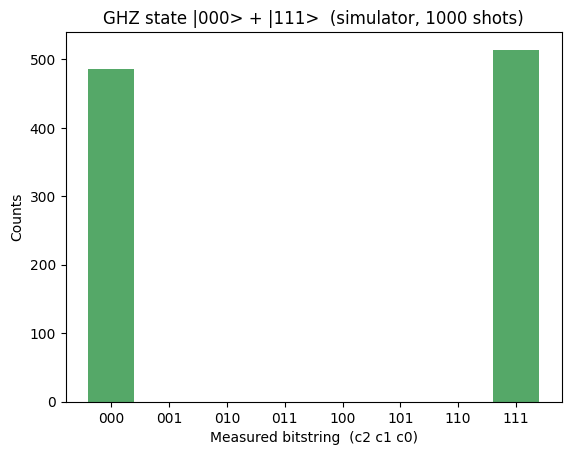

In [9]:
import matplotlib.pyplot as plt

labels = [format(i, "03b") for i in range(8)]   # 000 .. 111
values = [ghz_counts.get(b, 0) for b in labels]
plt.bar(labels, values, color="#55A868")
plt.title("GHZ state |000> + |111>  (simulator, 1000 shots)")
plt.xlabel("Measured bitstring  (c2 c1 c0)")
plt.ylabel("Counts")
plt.show()

**Observation:** only `000` and `111` appear (~50/50); all six mixed outcomes are absent. This is 3-qubit entanglement — the GHZ state.

### B.4 Run on the Quokka device

Strip the `qelib1.inc` include and POST the script, exactly as in Part A. **Update `QUOKKA_URL`** with the live address from your tutor.

In [10]:
import requests

ghz_clean = "\n".join(l for l in ghz_qasm.splitlines()
                      if not l.strip().startswith("include")) + "\n"

# quokka1..quokka5 exist; use whichever is online.
QUOKKA_URL = "http://quokka2.quokkacomputing.com/qsim/qasm"
SHOTS = 100

ghz_quokka = None
try:
    resp = requests.post(QUOKKA_URL, json={"script": ghz_clean, "count": SHOTS}, timeout=30)
    resp.raise_for_status()
    obj = resp.json()
    if obj.get("error_code", 0) != 0:
        raise RuntimeError("Quokka error: " + str(obj.get("error")))
    shot_list = list(obj["result"].values())[0]            # [[c0, c1, c2], ...] one per shot
    ghz_quokka = {}
    for shot in shot_list:
        key = "".join(str(int(b)) for b in reversed(shot))  # c2 c1 c0, matches Qiskit's ordering
        ghz_quokka[key] = ghz_quokka.get(key, 0) + 1
    print("Quokka GHZ counts:", ghz_quokka)
except Exception as e:
    print("Quokka not reachable right now:", type(e).__name__, "-", e)
    print("Try quokka1..quokka5 (one is usually online) and re-run on the college network.")

Quokka GHZ counts: {'000': 56, '111': 44}


### B.5 Conclusion

I designed and hand-wrote an OpenQASM 2.0 script for a **3-qubit GHZ state**, validated it in Qiskit,
confirmed on the simulator that it produces only the entangled outcomes `000` and `111`, and prepared
it to run on the Quokka device.

**Gates used in this assessment (Task 2):**

| Gate | QASM | Effect |
|------|------|--------|
| Hadamard | `h` | Creates an equal superposition $\tfrac{1}{\sqrt2}(|0\rangle+|1\rangle)$ |
| Pauli-X | `x` | Bit-flip $|0\rangle\leftrightarrow|1\rangle$ (Part A) |
| CNOT | `cx` | Flips the target qubit iff the control is 1 — the entangling gate |

Together, Parts A and B demonstrate superposition (H), a deterministic flip (X), and multi-qubit
entanglement (CX) authored both in Qiskit and directly in QASM.